In [1]:
import sys
sys.path.append("..")

from datetime import datetime
import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, sample_forward_process, interpolate_parameters
from physical_diffusion_fns.learning_fns import run_optimization, setup_force_matching_LOSS_and_GRADIENT_per_batch_analytical
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity, plot_parameter_as_fn_of_time, plot_sampels_energy_marginals_for_SGM_vs_ES
from physical_diffusion_fns.network_fns import setup_overdamped_SDE, solve_SDE, setup_energy_fn, setup_duffing_network_analytical_derivatives

jax.config.update("jax_enable_x64", True) 

# Random keys

In [2]:
master_key  = jax.random.PRNGKey(0)          # single seed
sample_target_key, optimization_key, reverse_sde_key = jr.split(master_key, 3)

# Generate samples from a mixture of 2 Gaussians in 2d - the target distribution

In [3]:
# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.6, .4])

# Define means
means = jnp.array([
    [1., 0.5],   # mean of first Gaussian
    [-1., -0.5],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.001, 0.0],    # covariance of first Gaussian
        [0.0, 0.001]],
    [[0.001, 0.0],   # covariance of second Gaussian
        [0.0, 0.001]],
])
# Generate samples
samples_target = sample_gaussian_mixture(sample_target_key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)

### Plot samples and marginal of target distributions

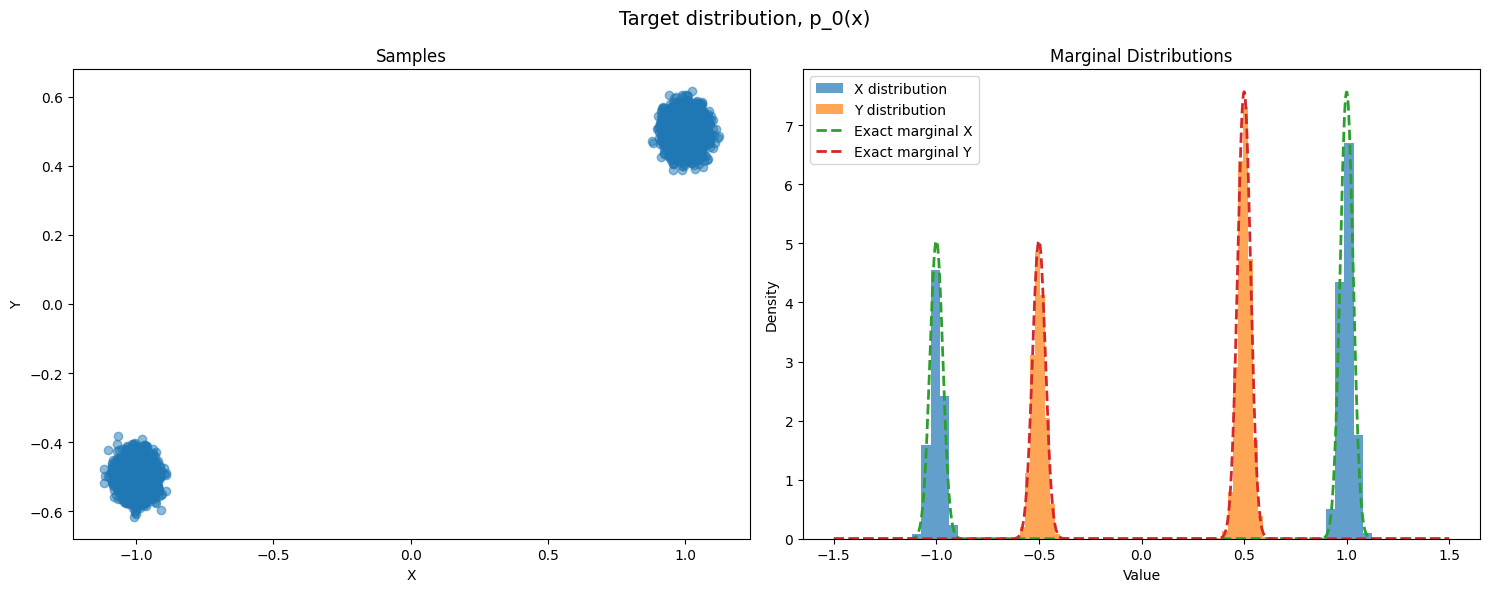

In [4]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_target[:, 0], samples_target[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_target[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_target[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

# Physical system

## Network size, topology and temperature

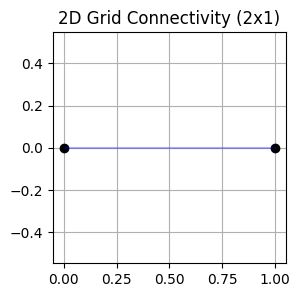

In [5]:
Temp = 0.75
N_osc = 2
connectivity = jnp.array([[0, 1]])
num_connections = connectivity.shape[0]
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

## Energy
Up to 6th order local energies and up to 4th order coupling energies

In [6]:
k_lin_0 = -1.*jnp.ones(N_osc)
k_duff_0 = jnp.ones(N_osc)
k_6_0 = jnp.ones(N_osc)
c_lin_0 = jnp.zeros(num_connections)
c_optomech_0 = jnp.zeros(num_connections)
c_duff_0 = jnp.zeros(num_connections)
biases_0 = jnp.zeros(N_osc)
params_initial = (k_lin_0, k_duff_0, k_6_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
params_names = ['k_lin', 'k_duff', 'k_6', 'c_lin', 'c_optomech', 'c_duff', 'biases']
params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
constraint_indices_k6_self = jnp.arange(2*N_osc,3*N_osc)
constraint_indices = constraint_indices_k6_self

# Set up energy fn
energy_fn = setup_energy_fn(connectivity, unflatten)
# Set up analytical derivatives
gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn = setup_duffing_network_analytical_derivatives(connectivity, unflatten)

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


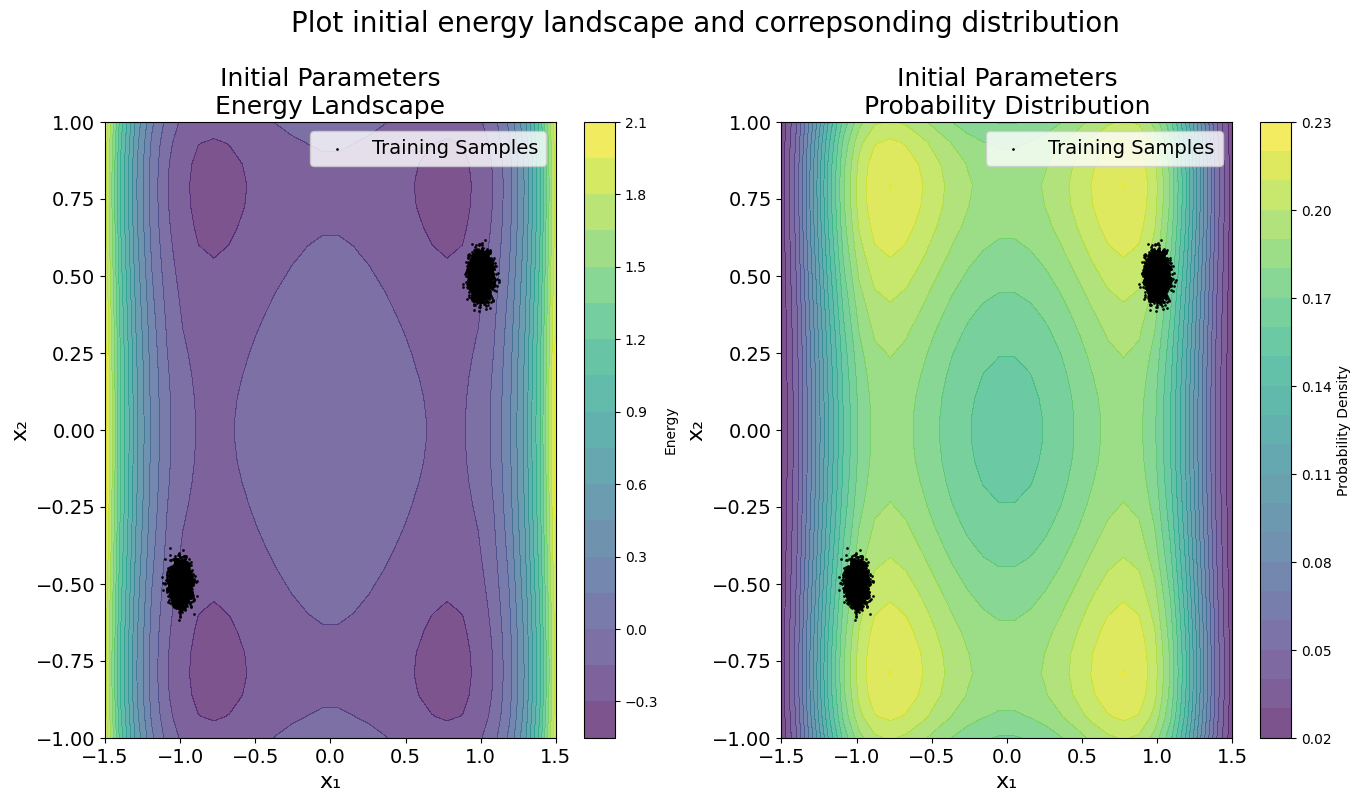

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_target,
    x1_range=(-1.5, 1.5),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape and correpsonding distribution" 
)

# Learning

In [8]:
# Use analytical version for much better performance
loss_fn_per_batch, gradient_fn_per_batch = setup_force_matching_LOSS_and_GRADIENT_per_batch_analytical(
    gradient_fn, trace_hessian_fn, gradient_wrt_params_fn, trace_hessian_wrt_params_fn, 
    k_b=1.0, T=Temp
)
maximize = False
learning_rate = Temp

#### Optimization parameters and filenames

In [9]:
# Forward process parameters
n_time_steps = 5
t_forward = 5.
forward_time_pts = jnp.linspace(0., t_forward, n_time_steps)

# Optimization parameters
n_epochs = 100000
batch_size = n_samples
window_size=50
tolerance=1e-1
patience=10

In [10]:
problem_type_folder = f"mixture_of_2_gaussians_in_2d"
physics_folder = f"Network_with_6th_order_local_and_duffing_coupling_energy"
temperature_folder = f"Temp_{Temp}"
optimization_folder = (
        f"t_forward_{t_forward}_"
        f"n_timesteps_{n_time_steps}_"
        f"lr_{learning_rate}_"
        f"epochs_{n_epochs}_"
        f"batch_{batch_size}_"
        f"window_{window_size}_"
        f"tol_{tolerance}_"
        f"patience_{patience}")

# Setup output directories
current_date = datetime.now().strftime("%Y_%m_%d")
# current_date = "2026_02_22"

base_dir = "../out"
output_dir = os.path.join(base_dir, current_date,problem_type_folder,physics_folder,temperature_folder, optimization_folder)
final_plots_folder = os.path.join(output_dir, 'final_plots')
optimization_plots_folder = os.path.join(output_dir, 'optimization_plots')

# Create directories if they don't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(final_plots_folder, exist_ok=True)
os.makedirs(optimization_plots_folder, exist_ok=True)
print(f"Final plots directory: {final_plots_folder}")
print(f"Optimization plots directory: {optimization_plots_folder}")

save_fig = True

Final plots directory: ../out/2026_07_06/mixture_of_2_gaussians_in_2d/Network_with_6th_order_local_and_duffing_coupling_energy/Temp_0.75/t_forward_5.0_n_timesteps_5_lr_0.75_epochs_100000_batch_10000_window_50_tol_0.1_patience_10/final_plots
Optimization plots directory: ../out/2026_07_06/mixture_of_2_gaussians_in_2d/Network_with_6th_order_local_and_duffing_coupling_energy/Temp_0.75/t_forward_5.0_n_timesteps_5_lr_0.75_epochs_100000_batch_10000_window_50_tol_0.1_patience_10/optimization_plots


No existing parameters found, running the optimization
t_idx: 0, t_curr: 0.0


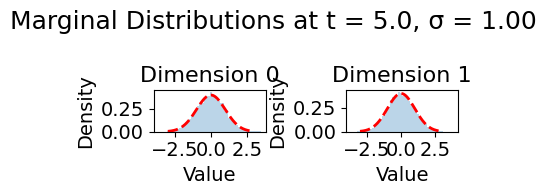

Epoch 0 - Loss: -8.4404 - Best Loss: -8.4404 (Epoch 0)
Epoch 100 - Loss: -534.5878 - Best Loss: -534.5878 (Epoch 100)
Epoch 200 - Loss: -739.7915 - Best Loss: -746.7081 (Epoch 198)
Epoch 300 - Loss: -808.2199 - Best Loss: -822.0441 (Epoch 296)
Epoch 400 - Loss: -837.5936 - Best Loss: -858.1374 (Epoch 373)
Epoch 500 - Loss: -863.1448 - Best Loss: -874.9463 (Epoch 454)
Epoch 600 - Loss: -871.9733 - Best Loss: -897.3347 (Epoch 557)
Epoch 700 - Loss: -891.2556 - Best Loss: -912.3253 (Epoch 628)
Epoch 800 - Loss: -890.9990 - Best Loss: -912.3253 (Epoch 628)
Epoch 900 - Loss: -895.9483 - Best Loss: -914.9087 (Epoch 888)
Epoch 1000 - Loss: -892.9145 - Best Loss: -921.5093 (Epoch 951)
Convergence reached at epoch 1000. Stopping optimization.
Best loss: -9.2151e+02
Found at epoch: 951


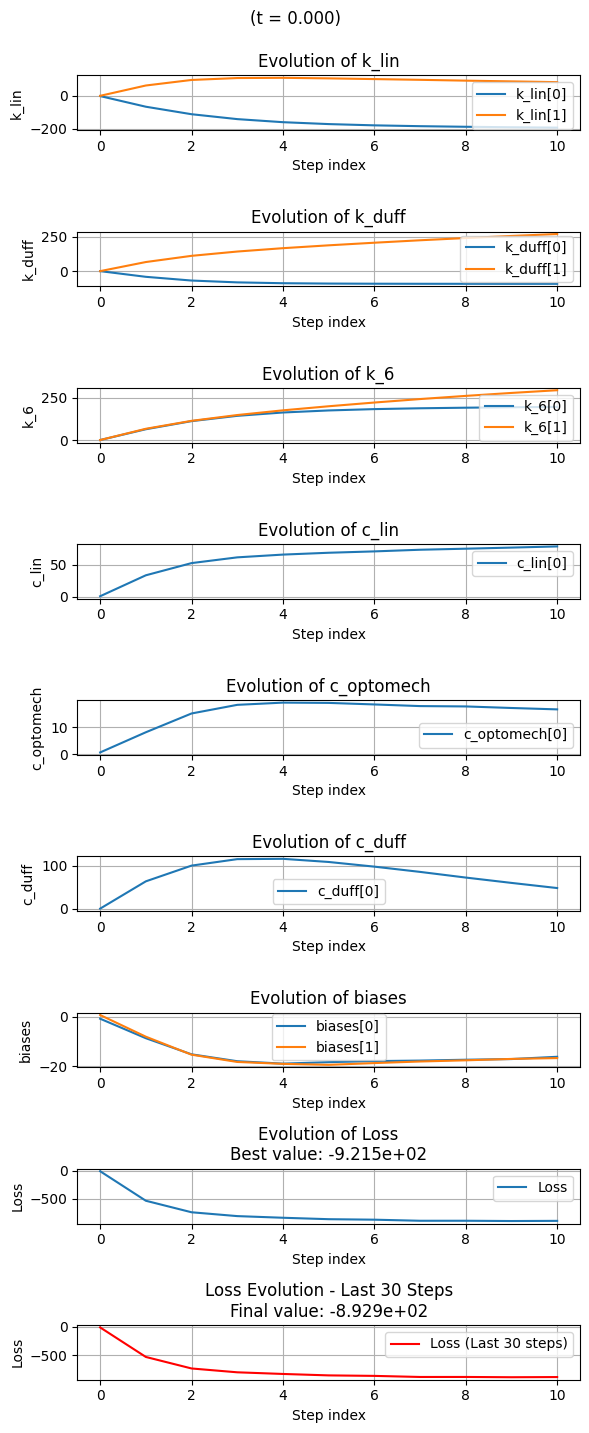

t_idx: 1, t_curr: 1.25
Epoch 0 - Loss: 23038186.9412 - Best Loss: 23038186.9412 (Epoch 0)
Epoch 100 - Loss: 11839420.3378 - Best Loss: 10027089.9377 (Epoch 95)
Epoch 200 - Loss: 6842767.4352 - Best Loss: 4323638.5080 (Epoch 199)
Epoch 300 - Loss: 4477446.4011 - Best Loss: 2438604.6831 (Epoch 297)
Epoch 400 - Loss: 1579000.3946 - Best Loss: 1569800.7776 (Epoch 397)
Epoch 500 - Loss: 1220004.7890 - Best Loss: 971183.5810 (Epoch 492)
Epoch 600 - Loss: 788213.5699 - Best Loss: 641740.8674 (Epoch 577)
Epoch 700 - Loss: 530620.7021 - Best Loss: 426024.1175 (Epoch 692)
Epoch 800 - Loss: 395156.8140 - Best Loss: 274694.5356 (Epoch 792)
Epoch 900 - Loss: 289600.5186 - Best Loss: 201397.7048 (Epoch 892)
Epoch 1000 - Loss: 151571.4893 - Best Loss: 142373.3119 (Epoch 983)
Convergence reached at epoch 1000. Stopping optimization.
Best loss: 1.4237e+05
Found at epoch: 983


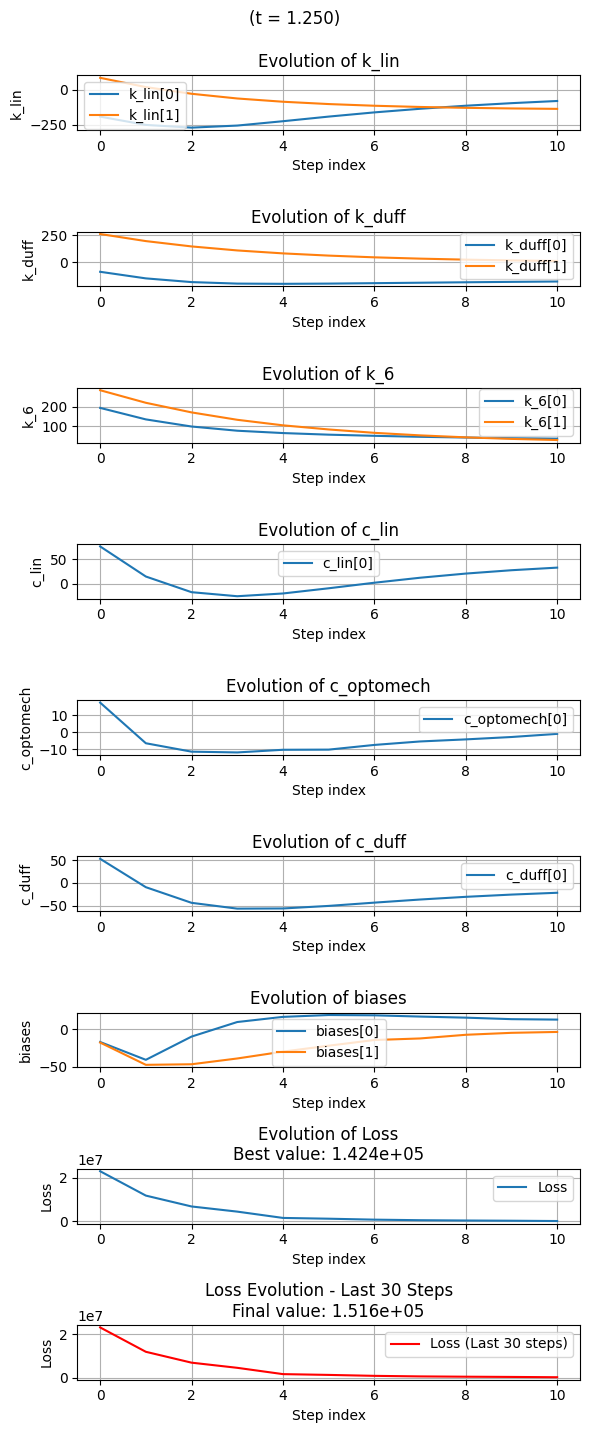

t_idx: 2, t_curr: 2.5
Epoch 0 - Loss: 189859.8809 - Best Loss: 189859.8809 (Epoch 0)
Epoch 100 - Loss: 18376.7956 - Best Loss: 17247.5587 (Epoch 99)
Epoch 200 - Loss: 7168.3039 - Best Loss: 5944.5671 (Epoch 198)
Epoch 300 - Loss: 1634.4023 - Best Loss: 1634.4023 (Epoch 300)
Epoch 400 - Loss: 903.3668 - Best Loss: 650.7412 (Epoch 385)
Epoch 500 - Loss: 396.7262 - Best Loss: 383.9882 (Epoch 497)
Epoch 600 - Loss: 329.5155 - Best Loss: 250.8022 (Epoch 598)
Epoch 700 - Loss: 269.6470 - Best Loss: 180.9785 (Epoch 697)
Epoch 800 - Loss: 154.4336 - Best Loss: 143.5540 (Epoch 770)
Epoch 900 - Loss: 133.0845 - Best Loss: 112.9104 (Epoch 879)
Epoch 1000 - Loss: 119.2502 - Best Loss: 87.1042 (Epoch 998)
Convergence reached at epoch 1000. Stopping optimization.
Best loss: 8.7104e+01
Found at epoch: 998


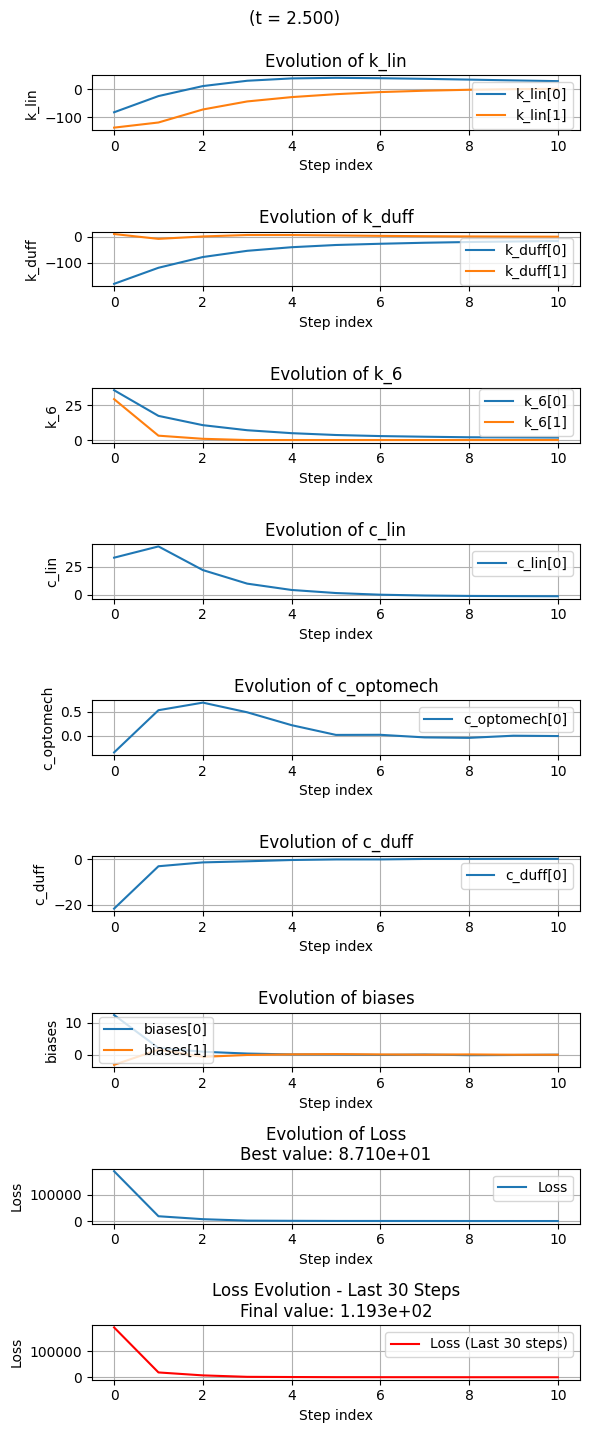

t_idx: 3, t_curr: 3.75
Epoch 0 - Loss: 102.1830 - Best Loss: 102.1830 (Epoch 0)
Epoch 100 - Loss: 0.7403 - Best Loss: 0.6615 (Epoch 92)
Epoch 200 - Loss: -1.3358 - Best Loss: -1.3502 (Epoch 197)
Epoch 300 - Loss: -1.3322 - Best Loss: -1.3588 (Epoch 238)
Epoch 400 - Loss: -1.3166 - Best Loss: -1.3667 (Epoch 366)
Epoch 500 - Loss: -1.2999 - Best Loss: -1.3667 (Epoch 366)
Epoch 600 - Loss: -1.3406 - Best Loss: -1.3751 (Epoch 507)
Epoch 700 - Loss: -1.3447 - Best Loss: -1.3751 (Epoch 507)
Epoch 800 - Loss: -1.3452 - Best Loss: -1.3751 (Epoch 507)
Epoch 900 - Loss: -1.3109 - Best Loss: -1.3751 (Epoch 507)
Epoch 1000 - Loss: -1.3273 - Best Loss: -1.3751 (Epoch 507)
Convergence reached at epoch 1000. Stopping optimization.
Best loss: -1.3751e+00
Found at epoch: 507


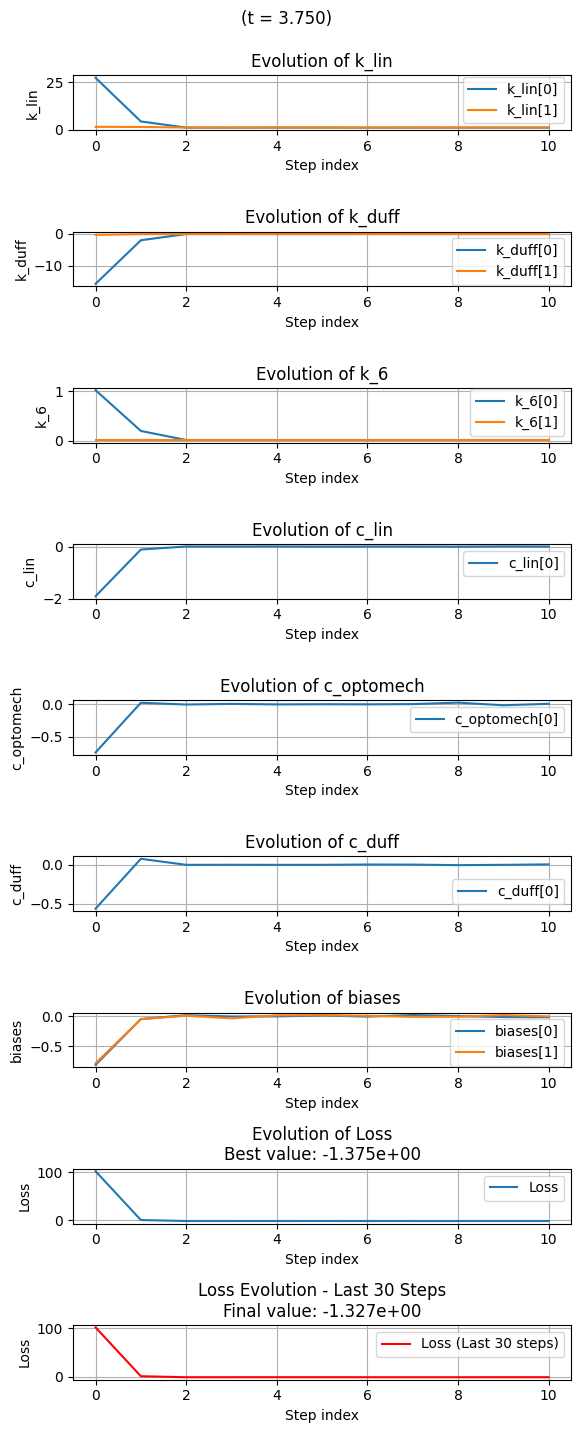

t_idx: 4, t_curr: 5.0
Epoch 0 - Loss: -1.3269 - Best Loss: -1.3269 (Epoch 0)
Epoch 100 - Loss: -1.3177 - Best Loss: -1.3547 (Epoch 95)
Epoch 200 - Loss: -1.3249 - Best Loss: -1.3610 (Epoch 139)
Epoch 300 - Loss: -1.3212 - Best Loss: -1.3682 (Epoch 265)
Epoch 400 - Loss: -1.3426 - Best Loss: -1.3682 (Epoch 265)
Epoch 500 - Loss: -1.3227 - Best Loss: -1.3682 (Epoch 265)
Epoch 600 - Loss: -1.3149 - Best Loss: -1.3722 (Epoch 557)
Epoch 700 - Loss: -1.3227 - Best Loss: -1.3722 (Epoch 557)
Epoch 800 - Loss: -1.3312 - Best Loss: -1.3722 (Epoch 557)
Epoch 900 - Loss: -1.3097 - Best Loss: -1.3906 (Epoch 847)
Epoch 1000 - Loss: -1.2989 - Best Loss: -1.3906 (Epoch 847)
Convergence reached at epoch 1000. Stopping optimization.
Best loss: -1.3906e+00
Found at epoch: 847


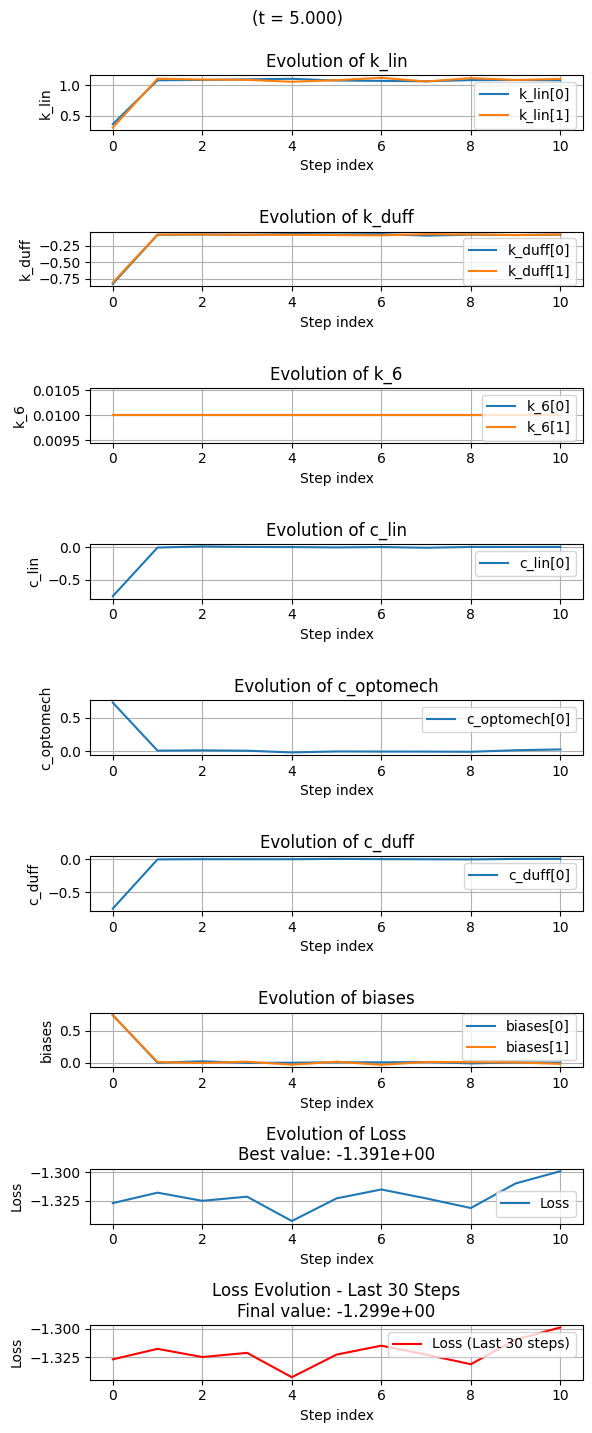

Optimization complete; saved parameters to ../out/2026_07_06/mixture_of_2_gaussians_in_2d/Network_with_6th_order_local_and_duffing_coupling_energy/Temp_0.75/t_forward_5.0_n_timesteps_5_lr_0.75_epochs_100000_batch_10000_window_50_tol_0.1_patience_10


In [11]:
# Setup optimization parameters
mask = jnp.ones(params_flattened_initial.shape[0])

# Plotting parameters
plot_steps = True  # Flag to control whether to plot during optimization
plot_slice = 1     # Plot every nth step

params_history_all_t = []
current_params = params_flattened_initial

params_history_path = f"{output_dir}/params_history.npy"
if os.path.exists(params_history_path):
    # Load existing parameters
    print('Loading existing parameters from', params_history_path)
    params_history_all_t = jnp.load(params_history_path)
else:
    print('No existing parameters found, running the optimization') 
    # Loop over time points
    for t_idx, t_curr in enumerate(forward_time_pts):
        print(f"t_idx: {t_idx}, t_curr: {t_curr}")
        optimization_key, optimization_subkey = jr.split(optimization_key)
        
        if t_idx == 0:
            samples_0 = sample_forward_process(t_forward, n_samples, D=1, sigma_final=1., samples0=samples_target, key=optimization_key)
            plot_forward_marginals(samples_0, t_forward, 1., beta=1.0, path=final_plots_folder, save_fig=save_fig, fontsize=16, plot_show=True)
        
        sampler = lambda key: sample_forward_process(
                t_curr, n_samples = batch_size, D=Temp, sigma_final=1., samples0=samples_target, key=key, beta= 1
            )
        
        # Perform optimization starting from previous best parameters
        params_history, loss_history, current_params, best_loss, best_epoch = run_optimization(
            loss_fn_per_batch=loss_fn_per_batch,
            params_initial=current_params,
            sampler=sampler,
            mask=mask,
            gradient_fn_per_batch=gradient_fn_per_batch,
            key=optimization_subkey,
            learning_rate=learning_rate,
            n_epochs=n_epochs,
            window_size=window_size,
            tolerance=tolerance,
            patience=patience,
            constraint_indices=constraint_indices
        )
        
        params_history_all_t.append(current_params)
        
        if plot_steps:
            if t_idx % plot_slice == 0:
                # Plot optimization progress
                plot_parameter_evolution(
                    params_history=params_history,
                    loss_history=loss_history,
                    best_params=current_params,
                    best_loss=best_loss,
                    best_idx=best_epoch,
                    time = t_curr,
                    time_index = t_idx,
                    unflatten=unflatten,
                    N_osc=N_osc,
                    title=f"(t = {t_curr:.3f})",
                    maximize=maximize,
                    labels_on=True,
                    save_fig=save_fig,
                    path=optimization_plots_folder,
                    param_names=params_names,
                    plot_show=True
                )
            
    # Convert params_history_all_t to array for easier analysis
    params_history_all_t = jnp.array(params_history_all_t)
    jnp.save(f"{output_dir}/params_history.npy", params_history_all_t)

print('Optimization complete; saved parameters to', output_dir)

### Interpolate and plot parameter evolution

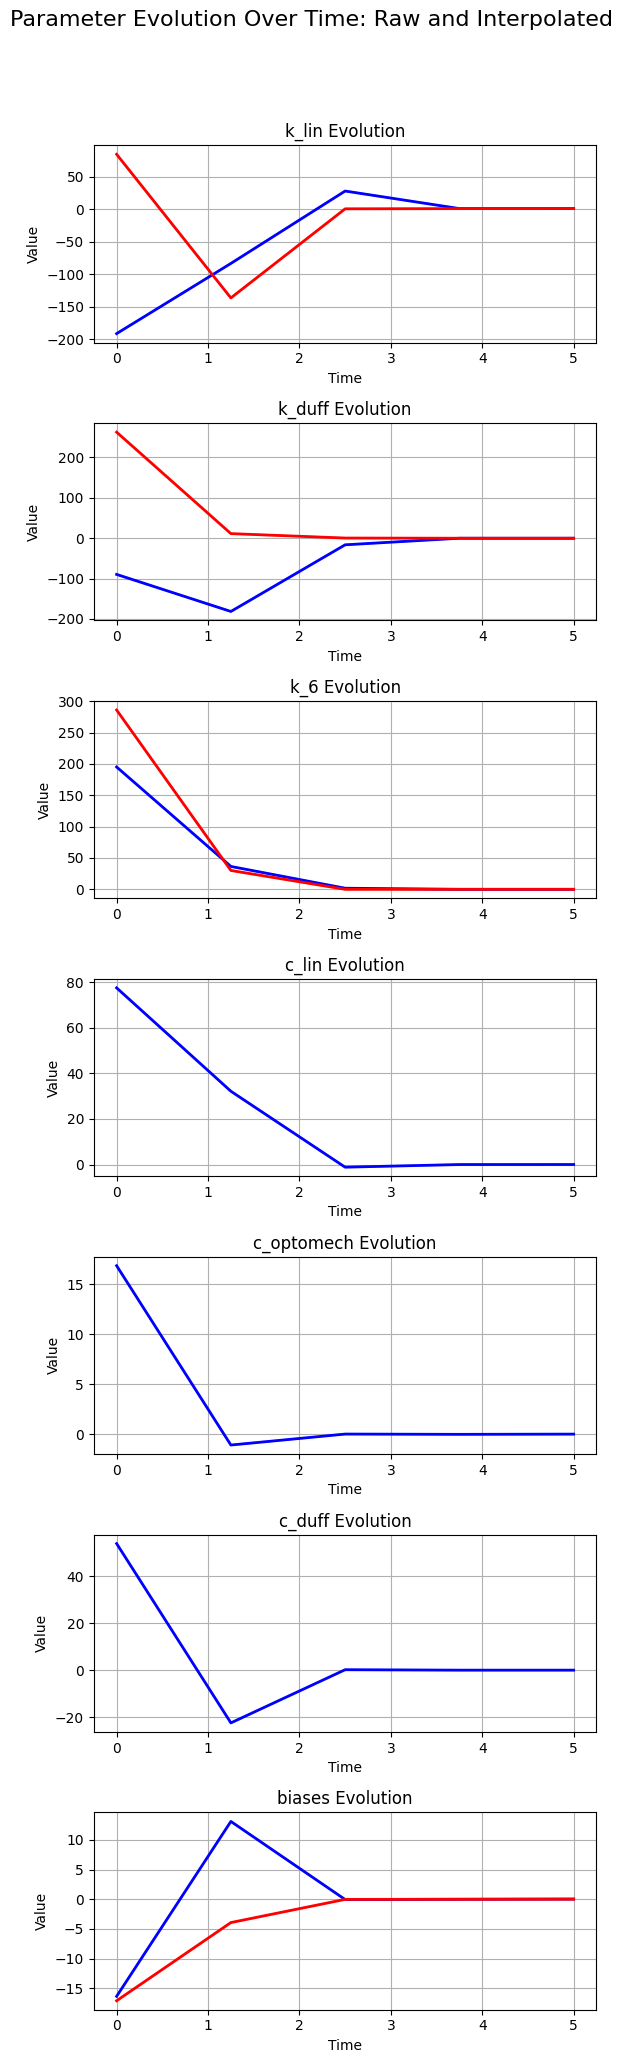

In [12]:
# Get interpolator functions
params_interpolator = interpolate_parameters(params_history_all_t, forward_time_pts)

plot_parameter_as_fn_of_time(params_names, forward_time_pts, forward_time_pts, params_history_all_t, params_interpolator, unflatten, N_osc, save_fig=True, path=final_plots_folder, log_scale=False,plot_show=True)


### Run reverse SDE:

In [13]:
forward_params = jnp.zeros_like(params_flattened_initial)
forward_params = forward_params.at[0:N_osc].set(1.)

params_interpolator_reverse_plus_linear = lambda t: 2*params_interpolator(t_forward - t) - forward_params


# Setup SDE functions
drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator_reverse_plus_linear, N_osc, time_dependent_parms=True, Temp=Temp)

t0 = 0.0
t1 = t_forward
ts = jnp.linspace(t0, t1, 100)
dt0 = 0.00000001
atol = 1e-2
rtol = 1e-3

n_trajectories = 2000

final_states_path = f"{output_dir}/SGM_samples_num_trajectories_{n_trajectories}_atol_{atol}_rtol_{rtol}.npy"

if os.path.exists(final_states_path):
    print(f"Loading existing final states from {final_states_path}")
    final_states = jnp.load(final_states_path)
else:
    print("No cached final states found, solving SDE...")
    # Generate multiple initial states from the asymptotic Gaussian N(0, Temp * I)
    reverse_sde_key, subkey_initial = jr.split(reverse_sde_key)
    initial_states = jnp.sqrt(Temp) * jr.normal(subkey_initial, shape=(n_trajectories, N))

    # Generate a key for each initial condition
    keys_brownian = jr.split(reverse_sde_key, n_trajectories)

    # Vectorize solve_SDE across both initial states and keys
    vectorized_solve_SDE = vmap(
        lambda init_state, key_b: solve_SDE(
            drift_fn,
            diffusion_fn,
            init_state,
            key_b,
            t0,
            t1,
            ts.shape[0],
            dt0,
            rtol=rtol,
            atol=atol
        ),
        in_axes=(0, 0)
    )

    # Run SDE for all initial states at once
    solutions = vectorized_solve_SDE(initial_states, keys_brownian)
    all_trajectories = solutions.ys
    final_states = all_trajectories[:, -1, :]

    jnp.save(final_states_path, final_states)
    print(f"Saved final states to {final_states_path}")

No cached final states found, solving SDE...


/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.wa

99.78%|#########9| [00:58<00:00,  1.82%/s] 

Saved final states to ../out/2026_07_06/mixture_of_2_gaussians_in_2d/Network_with_6th_order_local_and_duffing_coupling_energy/Temp_0.75/t_forward_5.0_n_timesteps_5_lr_0.75_epochs_100000_batch_10000_window_50_tol_0.1_patience_10/SGM_samples_num_trajectories_2000_atol_0.01_rtol_0.001.npy


100.00%|##########| [00:58<00:00,  1.70%/s]


### Run equillibirum SDE

In [14]:
fraction_of_trajectories_to_run = 0.00001
t1 = n_trajectories*t_forward*fraction_of_trajectories_to_run
sde_samples_direct_path = f"{output_dir}/equilibrium_sampling_fraction_{fraction_of_trajectories_to_run}.npy"
if os.path.exists(sde_samples_direct_path):
    # Load existing parameters
    print('Loading existing equilibrium trajectory', sde_samples_direct_path)
    sde_samples_direct = jnp.load(sde_samples_direct_path)
else:
    print('No existing equilibrium trajectory found, running optimization')   
    drift_fn, diffusion_fn = setup_overdamped_SDE(energy_fn, params_interpolator(0), N_osc, Temp=Temp, time_dependent_parms=False)
    t0 = 0.0
    ts = jnp.linspace(t0, t1, n_trajectories)
    dt0 = ts[1] - ts[0]
    initial_state = jnp.array([-.0,0.])

    reverse_sde_key, subkey_direct = jr.split(reverse_sde_key)
    solution_direct = solve_SDE(drift_fn, diffusion_fn, initial_state,subkey_direct, t0, t1, ts.shape[0], dt0,atol=atol,rtol=rtol)
    sde_samples_direct = solution_direct.ys
    jnp.save(sde_samples_direct_path, sde_samples_direct)


No existing equilibrium trajectory found, running optimization


/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/jax/_src/core.py:701: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.wa

## Plot samples

    Reverse Trajectory total prob ≈ 1.000000
  Equilibrium Sampling total prob ≈ 1.000000


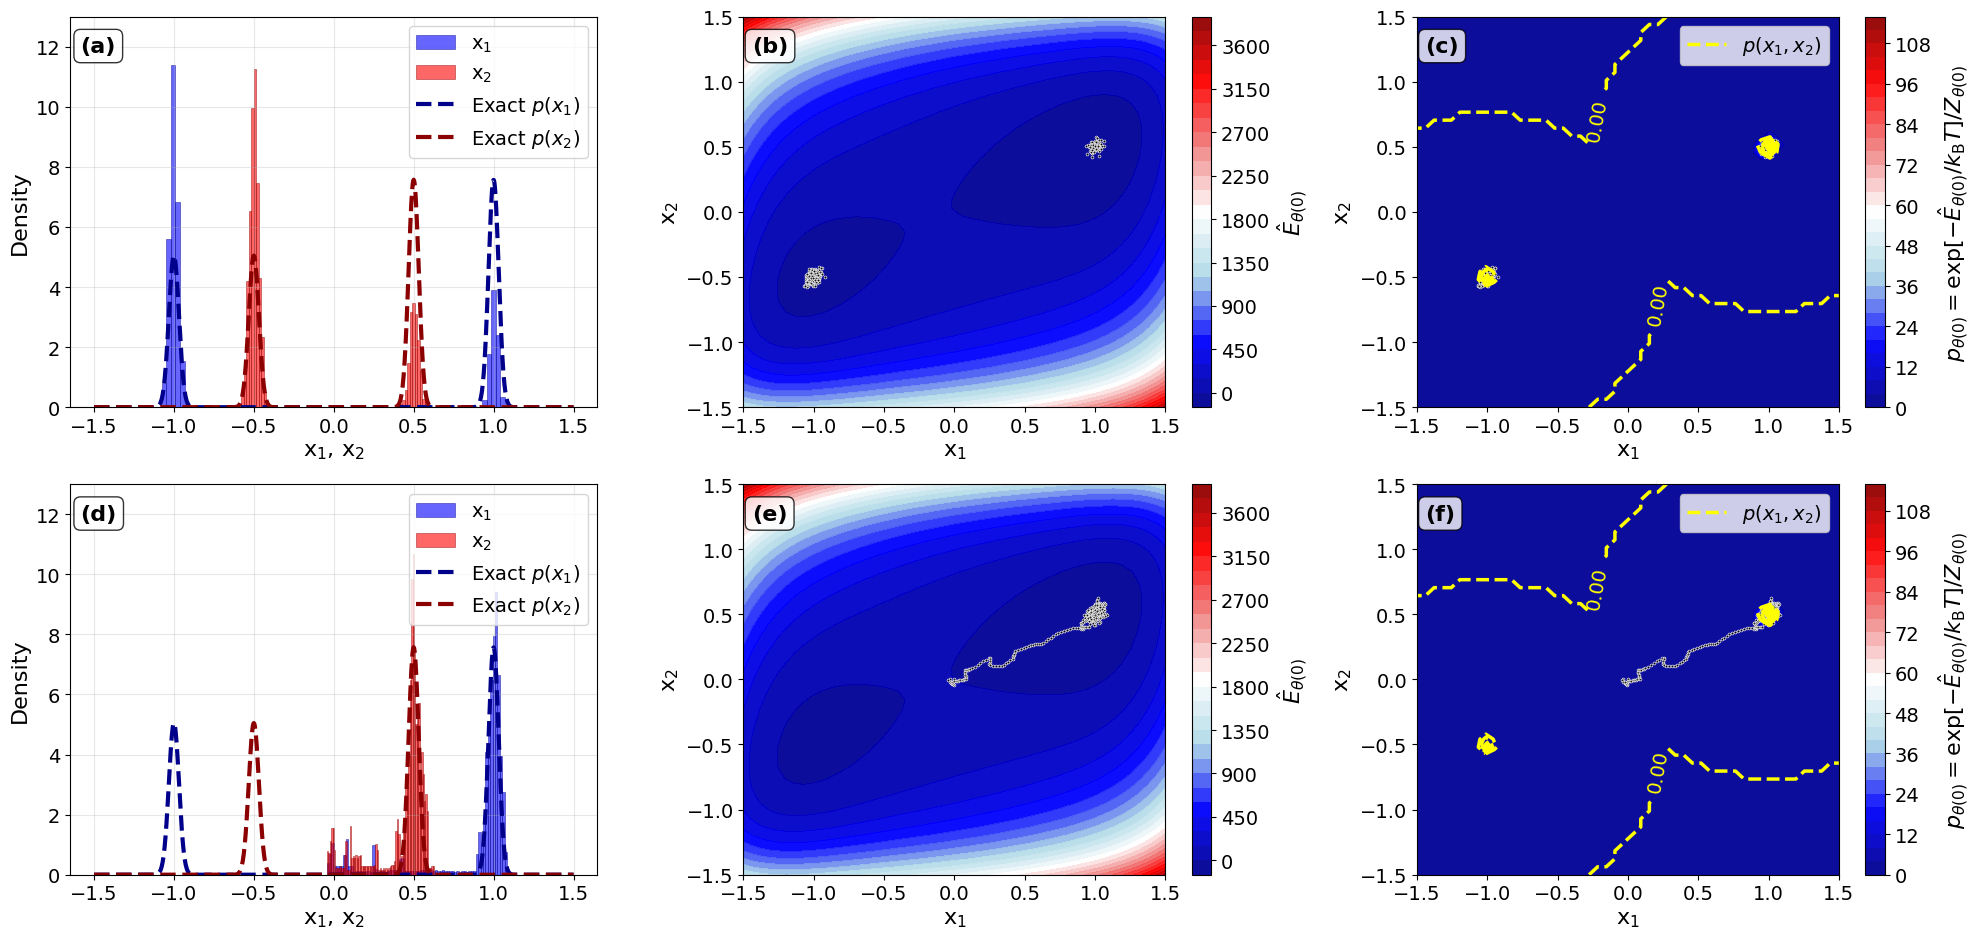

In [15]:
plot_sampels_energy_marginals_for_SGM_vs_ES(
    energy_fn,
    params_interpolator(0)/Temp,
    params_interpolator(0)/Temp,
    final_states,
    sde_samples_direct,
    weights, means, covs,
    n_points=50,
    num_bins=75,
    sample_stride=5,
    x1_range=(-1.5,1.5),
    x2_range=(-1.5,1.5),
    figsize=(20,10),
    fontsize=16,
    label_fontsize=16,
    iso_levels=7,
    colormap='bwr',
    contour_linewidth=2.5,
    scatter_size=4,
    scatter_alpha=0.9,
    plot_folder=final_plots_folder,
    n_trajectories=n_trajectories,
    atol=atol,
    rtol=rtol,
    Temp=Temp
)


In [16]:
# Estimate the covariance matrix from the final state samples
estimated_mean = jnp.mean(final_states, axis=0)
estimated_cov = jnp.cov(final_states.T)

# Theoretical covariance of the Gaussian mixture:
# μ_total = Σ_k w_k μ_k
# Σ_total = Σ_k w_k (Σ_k + μ_k μ_k^T) - μ_total μ_total^T
theoretical_mean = jnp.sum(weights[:, None] * means, axis=0)
theoretical_cov = sum(
    weights[k] * (covs[k] + jnp.outer(means[k], means[k]))
    for k in range(len(weights))
) - jnp.outer(theoretical_mean, theoretical_mean)

print("=== Mean ===")
print(f"  Estimated:   {estimated_mean}")
print(f"  Theoretical: {theoretical_mean}")
print()
print("=== Covariance Matrix ===")
print("  Estimated:")
print(f"    {estimated_cov}")
print("  Theoretical:")
print(f"    {theoretical_cov}")
print()
print("=== Element-wise relative error ===")
rel_err = jnp.abs(estimated_cov - theoretical_cov) / jnp.abs(theoretical_cov)
print(f"    {rel_err}")

=== Mean ===
  Estimated:   [-0.50403595 -0.25032088]
  Theoretical: [0.2 0.1]

=== Covariance Matrix ===
  Estimated:
    [[0.75025365 0.37516857]
 [0.37516857 0.18829409]]
  Theoretical:
    [[0.961 0.48 ]
 [0.48  0.241]]

=== Element-wise relative error ===
    [[0.21929901 0.21839882]
 [0.21839882 0.21869673]]


## Temperature as a hyperparameter

In [17]:
import json
import glob

# Assign each sample to its nearest theoretical mean (hard clustering)
n_components = len(weights)
dists = jnp.stack([jnp.sum((final_states - means[k]) ** 2, axis=1) for k in range(n_components)], axis=1)
assignments = jnp.argmin(dists, axis=1)

errors_record = {"Temp": float(Temp), "components": []}

print("=== Per-component Gaussian estimation (nearest-mean clustering) ===\n")
for k in range(n_components):
    mask = assignments == k
    cluster_samples = final_states[mask]
    n_k = jnp.sum(mask)

    w_est = float(n_k / len(final_states))
    mu_est = jnp.mean(cluster_samples, axis=0)
    cov_est = jnp.cov(cluster_samples.T)
    cov_th = covs[k]

    abs_err_weight = abs(w_est - float(weights[k]))
    abs_err_mean = jnp.abs(mu_est - means[k])
    abs_err_cov = jnp.abs(cov_est - cov_th)

    errors_record["components"].append({
        "weight_abs_err": float(abs_err_weight),
        "mean_abs_err": [float(v) for v in abs_err_mean],
        "cov_abs_err": [[float(v) for v in row] for row in abs_err_cov],
    })

    print(f"--- Component {k+1} (n={int(n_k)}) ---")
    print(f"  Weight:     {w_est:.6f}  (theoretical: {float(weights[k]):.6f})")
    print(f"  Mean:       {mu_est}  (theoretical: {means[k]})")
    print(f"  Covariance:")
    print(f"    Estimated:   {cov_est}")
    print(f"    Theoretical: {cov_th}")
    print(f"  Absolute errors:")
    print(f"    Weight: {abs_err_weight:.6f}")
    print(f"    Mean:   {abs_err_mean}")
    print(f"    Cov:    {abs_err_cov}")
    print()

# Also store the mixture-level absolute errors from the previous cell
errors_record["mixture"] = {
    "mean_abs_err": [float(v) for v in jnp.abs(estimated_mean - theoretical_mean)],
    "cov_abs_err": [[float(v) for v in row] for row in jnp.abs(estimated_cov - theoretical_cov)],
}

# Save errors — one file per temperature, all in the same shared directory
mixture_specifics = f"weights_{weights}_means_{means.flatten()}_covs_{covs.flatten()}"
errors_dir = os.path.join(base_dir, current_date, "hyperparameter_op", problem_type_folder, mixture_specifics)
os.makedirs(errors_dir, exist_ok=True)
errors_file = os.path.join(errors_dir, f"estimation_errors_Temp_{Temp}.json")

with open(errors_file, "w") as f:
    json.dump(errors_record, f)

print(f"Saved errors for Temp={Temp} to {errors_file}")
existing_files = sorted(glob.glob(os.path.join(glob.escape(errors_dir), "estimation_errors_Temp_*.json")))
print(f"Directory now contains {len(existing_files)} temperature file(s): {[os.path.basename(p) for p in existing_files]}")

=== Per-component Gaussian estimation (nearest-mean clustering) ===



--- Component 1 (n=497) ---
  Weight:     0.248500  (theoretical: 0.600000)
  Mean:       [1.00126379 0.50256383]  (theoretical: [1.  0.5])
  Covariance:
    Estimated:   [[0.00050605 0.0001183 ]
 [0.0001183  0.00074501]]
    Theoretical: [[0.001 0.   ]
 [0.    0.001]]
  Absolute errors:
    Weight: 0.351500
    Mean:   [0.00126379 0.00256383]
    Cov:    [[0.00049395 0.0001183 ]
 [0.0001183  0.00025499]]

--- Component 2 (n=1503) ---
  Weight:     0.751500  (theoretical: 0.400000)
  Mean:       [-1.00179641 -0.49927877]  (theoretical: [-1.  -0.5])
  Covariance:
    Estimated:   [[0.0006316  0.00026019]
 [0.00026019 0.00077043]]
    Theoretical: [[0.001 0.   ]
 [0.    0.001]]
  Absolute errors:
    Weight: 0.351500
    Mean:   [0.00179641 0.00072123]
    Cov:    [[0.0003684  0.00026019]
 [0.00026019 0.00022957]]

Saved errors for Temp=0.75 to ../out/2026_07_06/hyperparameter_op/mixture_of_2_gaussians_in_2d/weights_[0.6 0.4]_means_[ 1.   0.5 -1.  -0.5]_covs_[0.001 0.    0.    0.001 0.00

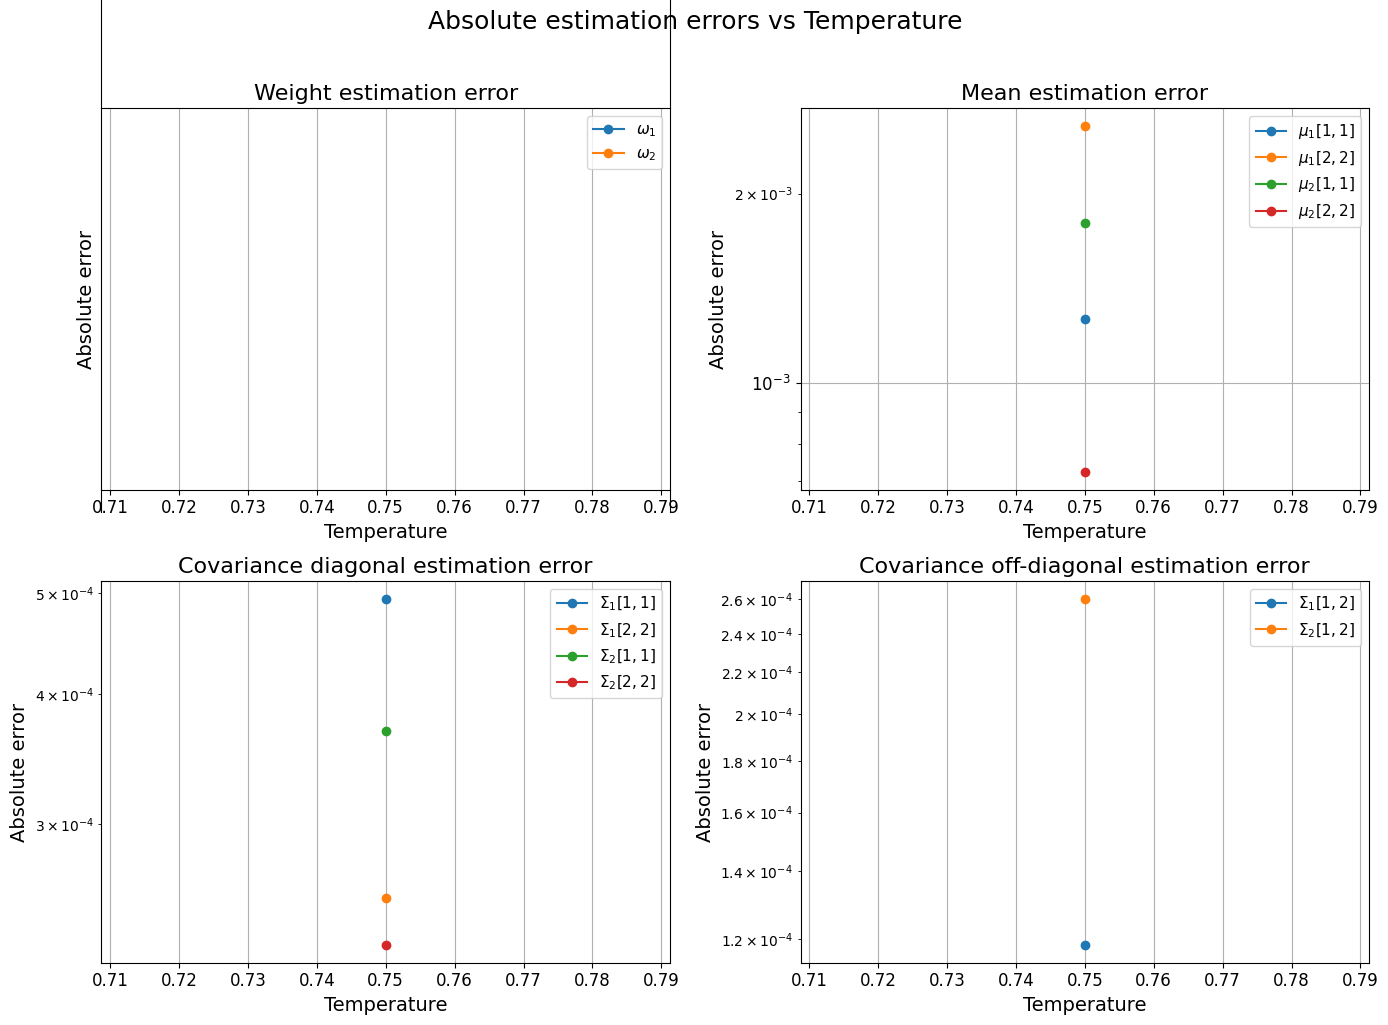

Loaded 1 temperature point(s): [0.75]


In [18]:
import json
import glob
import numpy as np

mixture_specifics = f"weights_{weights}_means_{means.flatten()}_covs_{covs.flatten()}"
errors_dir = os.path.join(base_dir, current_date, "hyperparameter_op", problem_type_folder, mixture_specifics)
plot_folder = errors_dir

seen = {}
escaped_dir = glob.escape(errors_dir)

# Load new per-temperature JSON files
for fpath in glob.glob(os.path.join(escaped_dir, "estimation_errors_Temp_*.json")):
    with open(fpath, "r") as f:
        rec = json.load(f)
        seen[rec["Temp"]] = rec

# Also pick up old-format .jsonl files from Temp_*/ subdirectories
for fpath in glob.glob(os.path.join(escaped_dir, "Temp_*", "estimation_errors_vs_temp.jsonl")):
    with open(fpath, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                rec = json.loads(line)
                seen.setdefault(rec["Temp"], rec)

records = sorted(seen.values(), key=lambda r: r["Temp"])
assert len(records) > 0, f"No error files found in {errors_dir}"

temps = np.array([r["Temp"] for r in records])
n_components = len(records[0]["components"])
dim = len(records[0]["components"][0]["mean_abs_err"])

LABEL_SIZE = 14
TITLE_SIZE = 16
TICK_SIZE = 12
LEGEND_SIZE = 11
SUPTITLE_SIZE = 18

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Weight errors ---
ax = axes[0, 0]
for k in range(n_components):
    errs = [r["components"][k]["weight_abs_err"] for r in records]
    ax.plot(temps, errs, "o-", label=rf"$\omega_{{{k+1}}}$")
ax.set_xlabel("Temperature", fontsize=LABEL_SIZE)
ax.set_ylabel("Absolute error", fontsize=LABEL_SIZE)
ax.set_yscale("log")
ax.set_title("Weight estimation error", fontsize=TITLE_SIZE)
ax.legend(fontsize=LEGEND_SIZE)
ax.tick_params(labelsize=TICK_SIZE)
ax.grid(True)

# --- Mean errors (per dimension) ---
ax = axes[0, 1]
for k in range(n_components):
    for d in range(dim):
        errs = [r["components"][k]["mean_abs_err"][d] for r in records]
        ax.plot(temps, errs, "o-", label=rf"$\mu_{{{k+1}}}[{d+1},{d+1}]$")
ax.set_xlabel("Temperature", fontsize=LABEL_SIZE)
ax.set_ylabel("Absolute error", fontsize=LABEL_SIZE)
ax.set_yscale("log")
ax.set_title("Mean estimation error", fontsize=TITLE_SIZE)
ax.legend(fontsize=LEGEND_SIZE)
ax.tick_params(labelsize=TICK_SIZE)
ax.grid(True)

# --- Covariance errors (diagonal elements) ---
ax = axes[1, 0]
for k in range(n_components):
    for d in range(dim):
        errs = [r["components"][k]["cov_abs_err"][d][d] for r in records]
        ax.plot(temps, errs, "o-", label=rf"$\Sigma_{{{k+1}}}[{d+1},{d+1}]$")
ax.set_xlabel("Temperature", fontsize=LABEL_SIZE)
ax.set_ylabel("Absolute error", fontsize=LABEL_SIZE)
ax.set_yscale("log")
ax.set_title("Covariance diagonal estimation error", fontsize=TITLE_SIZE)
ax.legend(fontsize=LEGEND_SIZE)
ax.tick_params(labelsize=TICK_SIZE)
ax.grid(True)

# --- Covariance errors (off-diagonal elements) ---
ax = axes[1, 1]
for k in range(n_components):
    for d1 in range(dim):
        for d2 in range(d1 + 1, dim):
            errs = [r["components"][k]["cov_abs_err"][d1][d2] for r in records]
            ax.plot(temps, errs, "o-", label=rf"$\Sigma_{{{k+1}}}[{d1+1},{d1+2}]$")
ax.set_xlabel("Temperature", fontsize=LABEL_SIZE)
ax.set_ylabel("Absolute error", fontsize=LABEL_SIZE)
ax.set_yscale("log")
ax.set_title("Covariance off-diagonal estimation error", fontsize=TITLE_SIZE)
ax.legend(fontsize=LEGEND_SIZE)
ax.tick_params(labelsize=TICK_SIZE)
ax.grid(True)

fig.suptitle("Absolute estimation errors vs Temperature", fontsize=SUPTITLE_SIZE, y=1.02)
fig.tight_layout()
plt.savefig(os.path.join(plot_folder, "estimation_errors_vs_temp.png"), dpi=300, bbox_inches="tight")
plt.show()

print(f"Loaded {len(records)} temperature point(s): {temps}")